In [1]:
import os
import urllib.request
import tarfile
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"The current used computation device is: {device}")

The current used computation device is: cuda


In [2]:
import torch
print(torch.__version__)

1.12.0+cu116


In [3]:
"""
    First Part
"""

# 1. Data preprocessing
# Must restrict Grayscale as the single channel, or otherwise will default to reading as 3 channels
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

# 2. Loading MNIST
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# 3. Download and unzip NotMNIST
notmnist_url = "http://yaroslavvb.com/upload/notMNIST/notMNIST_small.tar.gz"
notmnist_dir = "./data/notMNIST_small"
notmnist_tar = "./data/notMNIST_small.tar.gz"

if not os.path.exists(notmnist_dir):
    os.makedirs('./data', exist_ok=True)

    req = urllib.request.Request(
        notmnist_url,
        headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    )

    with urllib.request.urlopen(req) as response, open(notmnist_tar, 'wb') as out_file:
        out_file.write(response.read())

    print("Download complete, currently extracting")
    with tarfile.open(notmnist_tar, 'r:gz') as tar:
        tar.extractall(path='./data')
    print("Unzip complete")

# 4. Remove the damaged image
print("Checking for damaged images")
for root, dirs, files in os.walk(notmnist_dir):
    for filename in files:
        if filename.endswith('.png'):
            file_path = os.path.join(root, filename)
            try:
                with Image.open(file_path) as img:
                    img.verify()
            except (IOError, SyntaxError, Image.UnidentifiedImageError):
                print(f"Found the damaged file and remove: {file_path}")
                os.remove(file_path)
print("Remove completed")

# 5. Loading NotMNIST
ood_test = torchvision.datasets.ImageFolder(root=notmnist_dir, transform=transform)

# 6. Create DataLoader
batch_size = 100
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
test_loader_known = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)
test_loader_unknown = DataLoader(ood_test, batch_size=batch_size, shuffle=False)

# 7. Verification of the loading data
print("Successfully loading data")
print(f"The size of MNIST dataset: {len(mnist_train)}")
print(f"The size of NotMNIST (OOD) dataset: {len(ood_test)}")

# 8. Verify whether the dimension is aligned
images_mnist, _ = next(iter(test_loader_known))
images_notmnist, _ = next(iter(test_loader_unknown))
print(f"MNIST Batch Dimension: {images_mnist.shape}")
print(f"NotMNIST Batch Dimension: {images_notmnist.shape}")

Checking for damaged images
Remove completed
Successfully loading data
The size of MNIST dataset: 60000
The size of NotMNIST (OOD) dataset: 18724
MNIST Batch Dimension: torch.Size([100, 1, 28, 28])
NotMNIST Batch Dimension: torch.Size([100, 1, 28, 28])


In [4]:
"""
    Second Part
"""
import torch.nn as nn
import torch.nn.functional as F

# The three-layer MLP architecture, which is strictly replicated from the paper (support MC-dropout)
class DeepEnsembleMLP(nn.Module):
    def __init__(self, use_dropout=False):
        super(DeepEnsembleMLP, self).__init__()
        self.use_dropout = use_dropout

        # Input dimension: 28 * 28 = 784
        self.fc1 = nn.Linear(28 * 28, 200)
        self.bn1 = nn.BatchNorm1d(200)

        self.fc2 = nn.Linear(200, 200)
        self.bn2 = nn.BatchNorm1d(200)

        self.fc3 = nn.Linear(200, 200)
        self.bn3 = nn.BatchNorm1d(200)

        # Output layer: 10 categories (number 0-9)
        self.fc4 = nn.Linear(200, 10)

        # Section 3.4: For MC-dropout, dropout after each non-linearity with a 0.1 rate
        if self.use_dropout:
            self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        # Flatten images (batch_size, 1, 28, 28) -> (batch_size, 784)
        x = x.view(-1, 28 * 28)

        # Hidden layer: Fully connected -> Batch normalization -> ReLU -> Dropout
        x = F.relu(self.bn1(self.fc1(x)))
        if self.use_dropout:
            x = self.dropout(x)

        x = F.relu(self.bn2(self.fc2(x)))
        if self.use_dropout:
            x = self.dropout(x)

        x = F.relu(self.bn3(self.fc3(x)))
        if self.use_dropout:
            x = self.dropout(x)

        # The output layer does not need the activation function
        x = self.fc4(x)
        return x

# Compulsory turn on the Dropout in the evaluation
def apply_dropout(m):
    if type(m) == nn.Dropout:
        m.train()


# Test the basic model
model = DeepEnsembleMLP(use_dropout=False)

# Use the first batch in our test dataset for the trial run
images_test, _ = next(iter(test_loader_known))

outputs = model(images_test)

print("Successfully construct the model")
print(f"Input image dimension: {images_test.shape}")
print(f"Output image dimension: {outputs.shape}")

Successfully construct the model
Input image dimension: torch.Size([100, 1, 28, 28])
Output image dimension: torch.Size([100, 10])


In [5]:
"""
    Third Part
"""
import torch.optim as optim

# 1. Strictly align with the hyperparameters' settings in the paper
M_max = 10
num_epochs = 20
epsilon = 0.01
lr = 0.1

# 2. Prepare the list to store the four methods' model weights
weights_vanilla = []
weights_random = []
weights_at = []
weight_mc_dropout = None

criterion = nn.CrossEntropyLoss()

# 3. Unified training function
def train_model(method, use_dropout=False):
    model = DeepEnsembleMLP(use_dropout=use_dropout).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()

    for epoch in range(num_epochs):
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            # Method 1 & 4: Vanilla Ensemble and MC-dropout (without perturbation)
            if method == 'vanilla' or method == 'dropout':
                loss = criterion(model(images), labels)
                loss.backward()

            # Method 2 & 3: Ensemble with perturbation (AT and Random)
            else:
                images.requires_grad = True
                outputs_orig = model(images)
                loss_orig = criterion(outputs_orig, labels)
                loss_orig.backward(retain_graph=True)

                # Generate perturbation
                if method == 'at':
                    # Ensemble + AT
                    perturbation = epsilon * images.grad.data.sign()
                elif method == 'random':
                    # Ensemble + R
                    random_sign = torch.randint_like(images, 0, 2) * 2 - 1
                    perturbation = epsilon * random_sign

                # Constraint in the region of [0, 1]
                perturbed_images = torch.clamp(images + perturbation, 0, 1)

                # Calculate the loss for the perturbed samples
                outputs_adv = model(perturbed_images.detach())
                loss_adv = criterion(outputs_adv, labels)
                loss_adv.backward()

            optimizer.step()

    return model.state_dict()

# 4. Start to train all models
print(f"\nStart training the baseline model (M={M_max}, learning rate={lr})")

weight_mc_dropout = train_model('dropout', use_dropout=True)

for m in range(M_max):
    weights_vanilla.append(train_model('vanilla'))
    weights_random.append(train_model('random'))
    weights_at.append(train_model('at'))

print("\nAll models have been trained! The weights have been stored in memory.")


Start training the baseline model (M=10, learning rate=0.1)

All models have been trained! The weights have been stored in memory.


Calculate the metrics of Ensemble
Calculate the metrics of Ensemble + R
Calculate the metrics of Ensemble + AT
Calculate the metrics of MC dropout


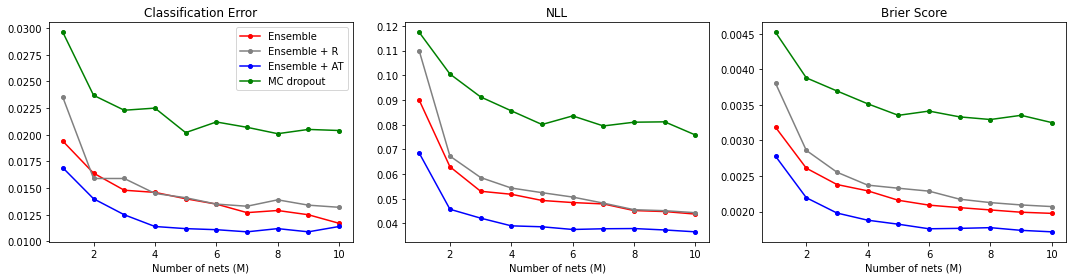

Calculate the entropy distribution of Ensemble
Calculate the entropy distribution of Ensemble + R
Calculate the entropy distribution of Ensemble + AT
Calculate the entropy distribution of MC dropout


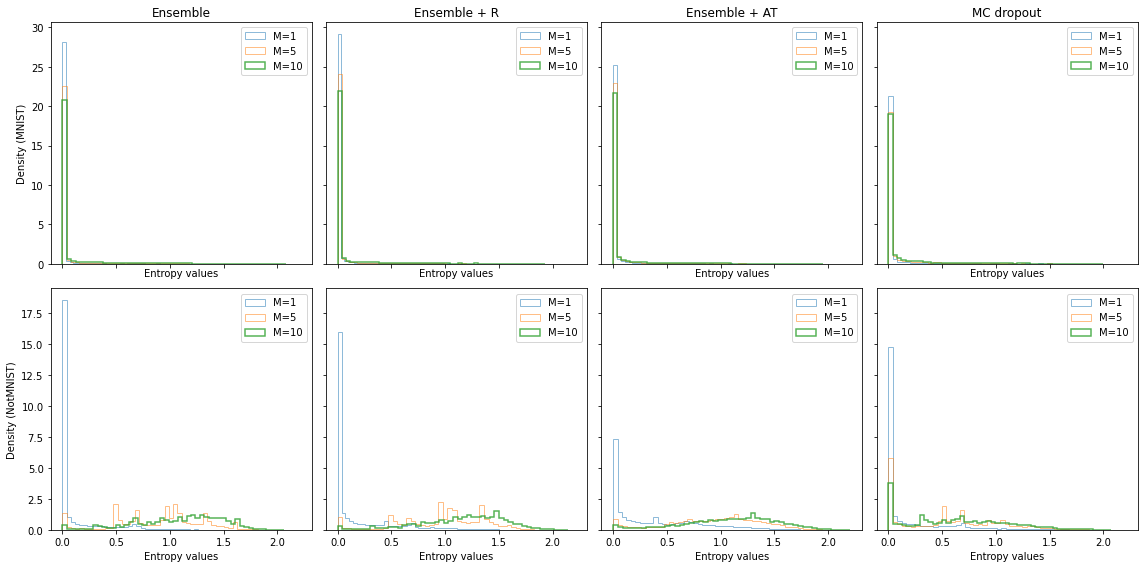

In [6]:
"""
    Fourth Part
"""

# 1. Core evaluation function
def get_predictions(method, weights, dataloader, m_val):

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            probs_list = []

            if method == 'dropout':
                # MC-dropout
                model = DeepEnsembleMLP(use_dropout=True).to(device)
                model.load_state_dict(weights)
                model.eval()
                model.apply(apply_dropout)
                for _ in range(m_val):
                    probs_list.append(F.softmax(model(images), dim=1))
            else:
                # Ensemble (Vanilla, Random, AT)
                for i in range(m_val):
                    model = DeepEnsembleMLP().to(device)
                    model.load_state_dict(weights[i])
                    model.eval()
                    probs_list.append(F.softmax(model(images), dim=1))

            avg_probs = torch.stack(probs_list).mean(dim=0)
            all_probs.append(avg_probs)
            all_labels.append(labels)

    return torch.cat(all_probs).cpu(), torch.cat(all_labels).cpu()

def calculate_metrics(probs, labels):
    # Classification Error
    preds = probs.argmax(dim=1)
    err = 1.0 - (preds == labels).float().mean().item()

    # NLL
    true_class_probs = probs[torch.arange(labels.size(0)), labels]
    nll = -torch.log(true_class_probs + 1e-12).mean().item()

    # Brier Score
    one_hot = F.one_hot(labels, num_classes=10).float()
    bs = (probs - one_hot).pow(2).sum(dim=1).mean().item() / 10.0

    return err, nll, bs

# 2. Replica of Figure 2a (4 curves)

M_range = list(range(1, M_max + 1))
methods_dict = {
    'Ensemble': weights_vanilla,
    'Ensemble + R': weights_random,
    'Ensemble + AT': weights_at,
    'MC dropout': weight_mc_dropout
}

# Store the results
results = {m: {'err':[], 'nll':[], 'bs':[]} for m in methods_dict}

# Iterate through all methods and all M values.
for method_name, w in methods_dict.items():
    print(f"Calculate the metrics of {method_name}")
    m_type = 'dropout' if 'dropout' in method_name else 'ensemble'
    for m in M_range:
        probs, labels = get_predictions(m_type, w, test_loader_known, m)
        err, nll, bs = calculate_metrics(probs, labels)
        results[method_name]['err'].append(err)
        results[method_name]['nll'].append(nll)
        results[method_name]['bs'].append(bs)

# Plot Figure 2a
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
metrics_keys = ['err', 'nll', 'bs']
titles = ['Classification Error', 'NLL', 'Brier Score']
colors = {'Ensemble':'red', 'Ensemble + R':'gray', 'Ensemble + AT':'blue', 'MC dropout':'green'}

for i, mk in enumerate(metrics_keys):
    for method_name in methods_dict:
        axes2[i].plot(M_range, results[method_name][mk], marker='o', markersize=4,
                      label=method_name, color=colors[method_name])
    axes2[i].set_title(titles[i])
    axes2[i].set_xlabel('Number of nets (M)')
    if i == 0: axes2[i].legend()
plt.tight_layout()
plt.show()

# 3. Replica of Figure 3a

target_M = [1, 5, 10]

fig3, axes3 = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey='row')
method_names = list(methods_dict.keys())

for col, method_name in enumerate(method_names):
    w = methods_dict[method_name]
    m_type = 'dropout' if 'dropout' in method_name else 'ensemble'
    print(f"Calculate the entropy distribution of {method_name}")

    for row, dataloader in enumerate([test_loader_known, test_loader_unknown]):
        dataset_name = 'MNIST' if row == 0 else 'NotMNIST'

        for m in target_M:
            probs, _ = get_predictions(m_type, w, dataloader, m)
            # H = -sum(p * log(p))
            entropy = -torch.sum(probs * torch.log(probs + 1e-12), dim=1).numpy()

            alpha = 0.5 if m != 10 else 0.8
            line_w = 1.5 if m == 10 else 1.0

            axes3[row, col].hist(entropy, bins=50, density=True, histtype='step',
                                 linewidth=line_w, label=f'M={m}', alpha=alpha)

        if row == 0: axes3[row, col].set_title(method_name)
        if col == 0: axes3[row, col].set_ylabel(f'Density ({dataset_name})')
        axes3[row, col].set_xlabel('Entropy values')
        axes3[row, col].legend(loc='upper right')

plt.tight_layout()
plt.show()

 Calculating the Accuracy vs Confidence of Ensemble
 Calculating the Accuracy vs Confidence of Ensemble + R
 Calculating the Accuracy vs Confidence of Ensemble + AT
 Calculating the Accuracy vs Confidence of MC dropout


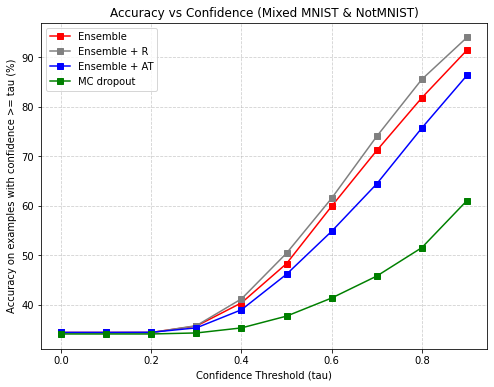

In [7]:
"""
    Fifth Part
"""

def eval_acc_vs_conf(probs_known, probs_unknown, labels_known):
    # 1. For known data (MNIST)
    conf_k, preds_k = probs_known.max(dim=1)
    corr_k = (preds_k == labels_known).numpy()

    # 2. For the unknow data NotMNIST
    # Because the category is not within the range of 0-9, the results it displays are all incorrect.
    conf_u, _ = probs_unknown.max(dim=1)
    corr_u = np.zeros_like(conf_u.numpy(), dtype=bool)

    # 3. Prediction results from combining two datasets
    mixed_conf = np.concatenate([conf_k.numpy(), conf_u.numpy()])
    mixed_corr = np.concatenate([corr_k, corr_u])

    # 4. Set different confidence filtering thresholds (tau from 0.0 to 0.9)
    thresholds = np.arange(0.0, 1.0, 0.1)
    accs = []
    for tau in thresholds:
        mask = mixed_conf >= tau
        if np.sum(mask) > 0:
            acc = np.mean(mixed_corr[mask])
        else:
            acc = 0.0
        accs.append(acc * 100)
    return thresholds, accs

plt.figure(figsize=(8, 6))

for method_name, w in methods_dict.items():
    print(f" Calculating the Accuracy vs Confidence of {method_name}")
    m_type = 'dropout' if 'dropout' in method_name else 'ensemble'

    # Obtain the predicted probability when M=10
    probs_k, labels_k = get_predictions(m_type, w, test_loader_known, 10)
    probs_u, _ = get_predictions(m_type, w, test_loader_unknown, 10)

    # Calculate accuracy at different thresholds
    t, a = eval_acc_vs_conf(probs_k, probs_u, labels_k)

    plt.plot(t, a, marker='s', label=method_name, color=colors[method_name])

plt.title('Accuracy vs Confidence (Mixed MNIST & NotMNIST)')
plt.xlabel('Confidence Threshold (tau)')
plt.ylabel('Accuracy on examples with confidence >= tau (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()